# COURSE: A deep understanding of deep learning
## SECTION: Understand and design CNNs
### LECTURE: The EMNIST dataset (letter recognition)
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [33]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
import copy
from sklearn.model_selection import train_test_split


# for importing data
import torchvision

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

from IPython.display import clear_output
import matplotlib.pyplot as plt

from scipy.stats import pearsonr


In [2]:
# use GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


# Import and inspect the data

In [3]:
# download the dataset
cdata = torchvision.datasets.EMNIST(root='emnist',split='letters',download=True)

# more info: https://www.nist.gov/itl/products-and-services/emnist-dataset

In [4]:
# inspect the data

# the categories (but how many letters??)
print(cdata.classes)
print(str(len(cdata.classes)) + ' classes')

print('\nData size:')
print(cdata.data.shape)

# transform to 4D tensor for conv layers (and transform from int8 to float)
images = cdata.data.view([124800,1,28,28]).float()
print('\nTensor data:')
print(images.shape)


['N/A', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
27 classes

Data size:
torch.Size([124800, 28, 28])

Tensor data:
torch.Size([124800, 1, 28, 28])


In [5]:
# brief aside: class 'N/A' doesn't exist in the data.
print( torch.sum(cdata.targets==0) )

# However, it causes problems in one-hot encoding...
torch.unique(cdata.targets)

tensor(0)


tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26])

In [6]:
cdata.class_to_idx

{'N/A': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [7]:
# so therefore we'll eliminate it and subtract 1 from the original

# remove the first class category
letterCategories = cdata.classes[1:]

# relabel labels to start at 0
labels = copy.deepcopy(cdata.targets)-1
print(labels.shape)

### 
print( torch.sum(labels==0) )
torch.unique(labels)

torch.Size([124800])
tensor(4800)


tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])

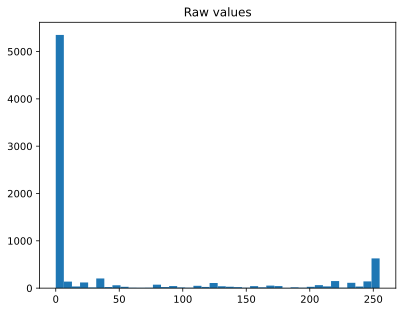

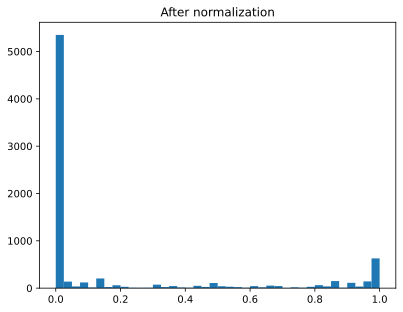

In [8]:
# next issue: do we need to normalize the images?
plt.hist(images[:10,:,:,:].view(-1).detach(),40);
plt.title('Raw values')
plt.show()

# yarp.
images /= torch.max(images)

plt.hist(images[:10,:,:,:].view(-1).detach(),40);
plt.title('After normalization')
plt.show()

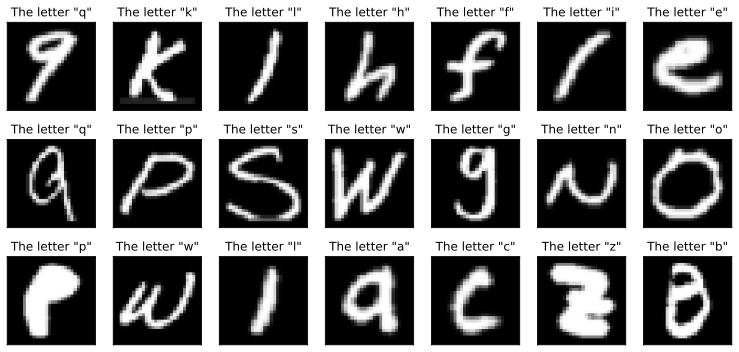

In [9]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax in enumerate(axs.flatten()):

  # pick a random pic
  whichpic = np.random.randint(images.shape[0])
  
  # extract the image and its target letter
  I = np.squeeze( images[whichpic,:,:] )
  letter = letterCategories[labels[whichpic]]
  
  # visualize
  ax.imshow(I.T,cmap='gray')
  ax.set_title('The letter "%s"'%letter)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create train/test groups using DataLoader

In [10]:
# Step 2: use scikitlearn to split the data into train/test/val sets
# 80% train, 10% test, 10% val
train_data,test_data, train_labels,test_labels = train_test_split(images, labels, test_size=.2)
test_data,val_data, test_labels,val_labels = train_test_split(test_data, test_labels, test_size=.5)

# Step 3: convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)
val_data   = TensorDataset(val_data,val_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])
val_loader   = DataLoader(val_data,batch_size=val_data.tensors[0].shape[0])

In [11]:
# check size (should be images X channels X width X height
print( train_loader.dataset.tensors[0].shape )
print( train_loader.dataset.tensors[1].shape )
print( test_loader.dataset.tensors[0].shape )
print( test_loader.dataset.tensors[1].shape )
print( val_loader.dataset.tensors[0].shape )
print( val_loader.dataset.tensors[1].shape )

torch.Size([99840, 1, 28, 28])
torch.Size([99840])
torch.Size([12480, 1, 28, 28])
torch.Size([12480])
torch.Size([12480, 1, 28, 28])
torch.Size([12480])


# Create the DL model

In [23]:
# create a class for the model
# This a more advanced model, where you can specify the number of layers. As we are testing it, we will have two models at the same time
def makeTheNet(printtoggle=False,cnnchannels=[6,6],ffnsizes=[50,50,26],kernelsize=3,padding=1,stride=1,maxpool=2,dropout=0):

  class emnistnet2(nn.Module):
    def __init__(self,printtoggle):
      super().__init__()
      
      self.print = printtoggle
      self.inputsize = 28
      self.channelsinput = 1
      self.cnnlayers = nn.ModuleList()
      self.bnorm1dlayers = nn.ModuleList()
      self.bnorm2dlayers = nn.ModuleList()
      self.ffnlayers = nn.ModuleList()
      expectedoutputs = []

      ### -------------- feature map layers -------------- ###
      for countercnn, cnnsize in enumerate(cnnchannels):
        if countercnn == 0:
          inputsize = self.channelsinput
          outputsize = cnnsize
        else:
          inputsize = cnnchannels[countercnn-1]
          outputsize = cnnsize

        convlayer = nn.Conv2d(inputsize,outputsize,kernelsize,padding=padding,stride=stride)
        bnorm = nn.BatchNorm2d(outputsize) # input the number of channels in this layer.

        self.cnnlayers.append(convlayer)
        self.bnorm2dlayers.append(bnorm)

        if countercnn == 0:
          expectedoutput = np.floor((np.floor((self.inputsize+2*padding-kernelsize)/stride)+1)/maxpool)
        else:
          expectedoutput = np.floor((np.floor((expectedoutputs[-1]+2*padding-kernelsize)/stride)+1)/maxpool)

        expectedoutputs.append(expectedoutput)
        if self.print: print(f'expected output: {int(expectedoutput)}')

      
      ### -------------- linear decision layers -------------- ###   
      if self.print: print(f'expected calculation: {int(expectedoutputs[-1])}*{int(expectedoutputs[-1])}*{int(cnnchannels[-1])}')

      for counterffn, size in enumerate(ffnsizes):
        if counterffn == 0:
          inputsize = int(expectedoutputs[-1]*expectedoutputs[-1]*cnnchannels[-1])
          outputsize = size
        else:
          inputsize = ffnsizes[counterffn-1]
          outputsize = size

        if counterffn == len(ffnsizes)-1:  # last layer
          # no batch norm on the last layer
          ffnlayer = nn.Linear(inputsize,outputsize)
          self.ffnlayers.append(ffnlayer)
        else:
          ffnlayer = nn.Linear(inputsize,outputsize)
          bnorm = nn.BatchNorm1d(outputsize)

          self.ffnlayers.append(ffnlayer)
          self.bnorm1dlayers.append(bnorm)

    def forward(self,x):
      
      if self.print: print(f'Input: {list(x.shape)}')

      for countercnn in range(len(self.cnnlayers)):
        x = F.max_pool2d(self.cnnlayers[countercnn](x),maxpool)
        x = F.leaky_relu(self.bnorm2dlayers[countercnn](x))
        x = F.dropout(x,dropout)
        if self.print: print(f'CPR block {countercnn}: {list(x.shape)}')

      # reshape for linear layer
      nUnits = x.shape.numel()/x.shape[0]
      x = x.view(-1,int(nUnits))
      if self.print: print(f'Vectorized: {list(x.shape)}')

      for counterffn in range(len(self.ffnlayers)):
        if counterffn == len(self.ffnlayers)-1:
          x = self.ffnlayers[counterffn](x)
        else:
          x = self.ffnlayers[counterffn](x)
          x = self.bnorm1dlayers[counterffn](x)
          x = F.leaky_relu(x)
          x = F.dropout(x,dropout)
          if self.print: print(f'Linear block {counterffn}: {list(x.shape)}')

      return x

  # create the model instance
  net = emnistnet2(printtoggle)
  
  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [26]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet(True)

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

net,lossfun,optimizer = makeTheNet(True, ffnsizes=[50,30,20,26])

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

net,lossfun,optimizer = makeTheNet(True, cnnchannels=[10,2,5])

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

net,lossfun,optimizer = makeTheNet(True, cnnchannels=[10,2,5],ffnsizes=[30,20,50,26])

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

print("Hola!")

expected output: 14
expected output: 7
expected calculation: 7*7*6
Input: [32, 1, 28, 28]
CPR block 0: [32, 6, 14, 14]
CPR block 1: [32, 6, 7, 7]
Vectorized: [32, 294]
Linear block 0: [32, 50]
Linear block 1: [32, 50]

Output size:
torch.Size([32, 26])
 
Loss:
tensor(3.4361, grad_fn=<NllLossBackward0>)
expected output: 14
expected output: 7
expected calculation: 7*7*6
Input: [32, 1, 28, 28]
CPR block 0: [32, 6, 14, 14]
CPR block 1: [32, 6, 7, 7]
Vectorized: [32, 294]
Linear block 0: [32, 50]
Linear block 1: [32, 30]
Linear block 2: [32, 20]

Output size:
torch.Size([32, 26])
 
Loss:
tensor(3.3247, grad_fn=<NllLossBackward0>)
expected output: 14
expected output: 7
expected output: 3
expected calculation: 3*3*5
Input: [32, 1, 28, 28]
CPR block 0: [32, 10, 14, 14]
CPR block 1: [32, 2, 7, 7]
CPR block 2: [32, 5, 3, 3]
Vectorized: [32, 45]
Linear block 0: [32, 50]
Linear block 1: [32, 50]

Output size:
torch.Size([32, 26])
 
Loss:
tensor(3.3247, grad_fn=<NllLossBackward0>)
expected output: 

# Create a function that trains the model

In [27]:
# a function that trains the model

def function2trainTheModel(cnnchannels=[6,6],ffnsizes=[50,50,26],kernelsize=3,padding=1,stride=1,maxpool=2,dropout=0,numepochs=12, val=False):

  # number of epochs
  numepochs = numepochs
  
  # create a new model
  net,lossfun,optimizer = makeTheNet(False, cnnchannels=cnnchannels, ffnsizes=ffnsizes, kernelsize=kernelsize, padding=padding, stride=stride, maxpool=maxpool, dropout=dropout)

  # send the model to the GPU
  net.to(device)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)
  trainErr  = torch.zeros(numepochs)
  testErr   = torch.zeros(numepochs)

  # select loader 
  if val: 
    train_loader_selected = train_loader
    test_loader_selected  = val_loader
  else:
    train_loader_selected = train_loader
    test_loader_selected  = test_loader

  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    net.train()
    batchLoss = []
    batchErr  = []
    for X,y in train_loader_selected:

      # push data to GPU
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss and error from this batch
      batchLoss.append(loss.item())
      batchErr.append( torch.mean((torch.argmax(yHat,axis=1) != y).float()).item() )
    # end of batch loop...

    # and get average losses and error rates across the batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainErr[epochi]  = 100*np.mean(batchErr)



    ### test performance
    net.eval()
    X,y = next(iter(test_loader_selected)) # extract X,y from test dataloader

    # push data to GPU
    X = X.to(device)
    y = y.to(device)

    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y)
      
    # get loss and error rate from the test batch
    testLoss[epochi] = loss.item()
    testErr[epochi]  = 100*torch.mean((torch.argmax(yHat,axis=1) != y).float()).item()

  # end epochs

  # function output
  return trainLoss,testLoss,trainErr,testErr,net

# Run the experiment

We are going to run the experiment of all the possible combinations of [2,5,8] in two layers.

In [28]:
layers1 = [2,5,8]
layers2 = [2,5,8]

trainlosses = [[0 for _ in range(len(layers2))] for _ in range(len(layers1))]
testlosses = [[0 for _ in range(len(layers2))] for _ in range(len(layers1))]
trainerrs = [[0 for _ in range(len(layers2))] for _ in range(len(layers1))]
testerrs = [[0 for _ in range(len(layers2))] for _ in range(len(layers1))]

for i, layer1 in enumerate(layers1):
    for j, layer2 in enumerate(layers2):
        runtrainlosses = []
        runtestlosses = []
        runtrainerrs = []
        runtesterrs = []

        for _ in range(3):
            # train the model
            trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(cnnchannels=[layer1,layer2],numepochs=5)
            runtrainlosses.append(trainLoss)
            runtestlosses.append(testLoss)
            runtrainerrs.append(trainErr)
            runtesterrs.append(testErr)

        trainlosses[i][j] = torch.mean(torch.stack(runtrainlosses), axis=0)
        testlosses[i][j] = torch.mean(torch.stack(runtestlosses), axis=0)
        trainerrs[i][j] = torch.mean(torch.stack(runtrainerrs), axis=0)
        testerrs[i][j] = torch.mean(torch.stack(runtesterrs), axis=0)

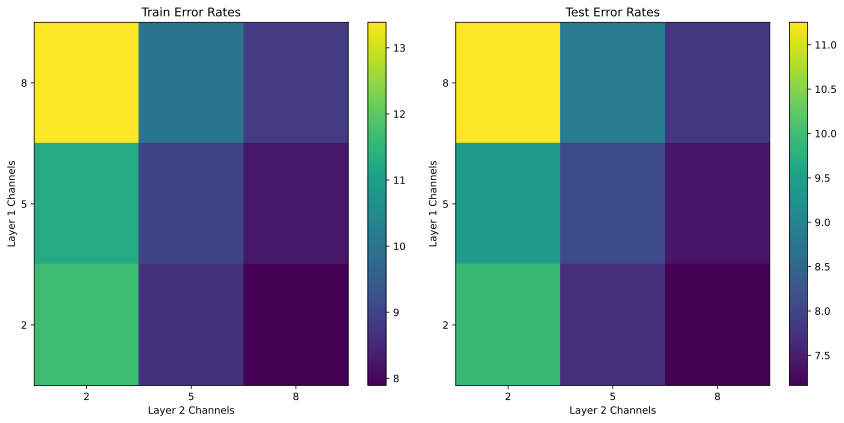

In [ ]:
# Convert the final error rates to numpy arrays for easier manipulation
trainerrs_final = np.array([[trainerrs[i][j][-1] for j in range(3)] for i in range(3)])
testerrs_final = np.array([[testerrs[i][j][-1] for j in range(3)] for i in range(3)])

# Plot the matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Train error rates
im1 = axs[0].imshow(trainerrs_final, cmap='viridis', aspect='auto')
axs[0].set_title('Train Error Rates')
axs[0].set_xlabel('Layer 2 Channels')
axs[0].set_ylabel('Layer 1 Channels')
axs[0].set_xticks(range(3))
axs[0].set_yticks(range(3))
axs[0].set_xticklabels([2, 5, 8])
axs[0].set_yticklabels([8, 5, 2])
fig.colorbar(im1, ax=axs[0])

# Test error rates
im2 = axs[1].imshow(testerrs_final, cmap='viridis', aspect='auto')
axs[1].set_title('Test Error Rates')
axs[1].set_xlabel('Layer 2 Channels')
axs[1].set_ylabel('Layer 1 Channels')
axs[1].set_xticks(range(3))
axs[1].set_yticks(range(3))
axs[1].set_xticklabels([2, 5, 8])
axs[1].set_yticklabels([8, 5, 2])
fig.colorbar(im2, ax=axs[1])

# Show the plot
plt.tight_layout()
plt.show()

In [1]:
errordict = {}

for i in range(len(layers1)):
    for j in range(len(layers2)):
        totalchannels = layers1[i] * layers2[j]
        trainerror = trainerrs[i][j][-1]
        testerror = testerrs[i][j][-1]

        if totalchannels not in errordict:
            errordict[totalchannels] = {'train': [], 'test': []}
        errordict[totalchannels]['train'].append(trainerror)
        errordict[totalchannels]['test'].append(testerror)

# Prepare data for plotting
total_channels = sorted(errordict.keys())
train_errors = [np.mean(errordict[tc]['train']) for tc in total_channels]
test_errors = [np.mean(errordict[tc]['test']) for tc in total_channels]

# Calculate correlations
train_corr, _ = pearsonr(total_channels, train_errors)
test_corr, _ = pearsonr(total_channels, test_errors)

# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(total_channels, train_errors, 'o-', label='Train Errors (r= {:.2f})'.format(train_corr), color='blue')
plt.plot(total_channels, test_errors, 's-', label='Test Errors (r= {:.2f})'.format(test_corr), color='orange')

# Add labels, title, and legend
plt.xlabel('Total Channels', fontsize=12)
plt.ylabel('Error Rate (%)', fontsize=12)
plt.title('Error Rates vs Total Channels', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'layers1' is not defined